In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ad_afqmc import (
    lattices,
    hf_guess,
)

In [2]:
import matplotlib as mpl
import matplotlib.font_manager as font_manager
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib import rcParams
import matplotlib.colors as mcolors
plt.rc('font',family='serif')
plt.rc('xtick',labelsize=18)
plt.rc('ytick',labelsize=18)
plt.rc('axes',labelsize=20)
plt.rc('axes',titlesize=20)
plt.rc('legend',fontsize=16)
plt.rc('lines', linewidth=2)
plt.rc('savefig', dpi=300)

plt.rcParams['figure.autolayout'] =  True
plt.rcParams["font.family"] = "Serif"
cmfont = font_manager.FontProperties(fname=mpl.get_data_path() + '/fonts/ttf/cmr10.ttf')
mpl.rcParams['font.serif'] = cmfont.get_name()
plt.rcParams["axes.formatter.use_mathtext"] = True
mpl.rcParams['mathtext.fontset'] = 'cm'
mpl.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = [10, 8]
colors = list(mcolors.TABLEAU_COLORS.values())

In [3]:
def _get_bond_charge_current(lattice, dm):
    dm_aa = dm[:n_sites, :n_sites]
    dm_bb = dm[n_sites:, n_sites:]
    dm_charge = dm_aa + dm_bb
    
    has_bond = np.zeros((n_sites, n_sites), dtype=bool)
    is_pbc_bond = np.zeros((n_sites, n_sites), dtype=bool)
    Jbond = np.zeros((n_sites, n_sites), dtype=float)
    neighbors = [[] for _ in range(n_sites)]
    h1 = lattice.create_adjacency_matrix()
    
    for i, (x, y) in enumerate(lattice.sites):
        Xi, Yi = coords[i]
        
        for nn in lattice.get_nearest_neighbors((x, y)):
            xn, yn = int(nn[0]), int(nn[1])
            if not (0 <= xn < nx and 0 <= yn < ny):
                continue
            j = lattice.get_site_num((xn, yn))
            if j <= i:
                continue
    
            Xj, Yj = coords[j]
    
            is_pbc = (abs(xn - x) > 1) or (abs(yn - y) > 1)
    
            # store adjacency
            has_bond[i, j] = has_bond[j, i] = True
            is_pbc_bond[i, j] = is_pbc_bond[j, i] = is_pbc
            neighbors[i].append(j)
            neighbors[j].append(i)
    
            # bond current (or 0 if not needed)
            Jij = 0.0
            tij = h1[i, j]
            if tij != 0:
                Jij = 2.0 * np.imag(tij * dm_charge[i, j])
            Jbond[i, j] = Jij
            Jbond[j, i] = -Jij

    return Jbond

def get_bond_charge_current(lattice, dm):
    n_sites = lattice.n_sites
    adjacency = lattice.create_adjacency_matrix()
    dm_aa = dm[:n_sites, :n_sites]
    dm_bb = dm[n_sites:, n_sites:]
    dm_charge = dm_aa + dm_bb
    mod_dm = adjacency * -1.j * dm_charge
    Jbond = mod_dm - mod_dm.T
    return Jbond

def get_plaquette_charge_current(lattice, Jbond):
    n_sites = lattice.n_sites
    coords = np.array([lattice.get_site_coordinate(site) for site in lattice.sites])
    adjacency = lattice.create_adjacency_matrix()
    y_boundary_pairs = [0., max(coords[:, 1])]
    
    plaquette_coords = []
    plaquettes = []
    J_plaquettes = []

    for i in range(n_sites):
        nn = np.nonzero(adjacency[i])[0]
            
        for idx_j, j in enumerate(nn):
            if j <= i: continue

            for k in nn[idx_j:]:
                if (k <= i): continue
                if adjacency[j, k] == 0: continue

                xi, yi = coords[i]
                xj, yj = coords[j]
                xk, yk = coords[k]
            
                if np.allclose([yi, yj], y_boundary_pairs) or np.allclose([yi, yj], y_boundary_pairs[::-1]): continue
                if np.allclose([yi, yk], y_boundary_pairs) or np.allclose([yi, yk], y_boundary_pairs[::-1]): continue
                if np.allclose([yj, yk], y_boundary_pairs) or np.allclose([yj, yk], y_boundary_pairs[::-1]): continue

                area2 = (xj - xi) * (yk - yi) - (xk - xi) * (yj - yi)
                if np.isclose(area2, 0.0): continue  # degenerate

                if area2 > 0:
                    plaquette = [i, j, k]
                    plaquette_coord = [(xi, yi), (xj, yj), (xk, yk)]
                    J_plaquette = Jbond[i, j] + Jbond[j, k] + Jbond[k, i]
                    
                else:
                    plaquette = [i, k, j]
                    plaquette_coord = [(xi, yi), (xk, yk), (xj, yj)]
                    J_plaquette = Jbond[i, k] + Jbond[k, j] + Jbond[j, i]

                plaquettes.append(plaquette)
                plaquette_coords.append(plaquette_coord)
                J_plaquettes.append(J_plaquette)

    return plaquettes, plaquette_coords, J_plaquettes

# Load data

In [4]:
path = './data/'
npz_xc_6x6_dat = np.load(f'{path}xc_6x6_ghf_data.npz')
npz_yc_6x6_dat = np.load(f'{path}yc_6x6_ghf_data.npz')
npz_xc_6x6_rdm1 = np.load(f'{path}xc_6x6_ghf_rdm1s.npz')
npz_yc_6x6_rdm1 = np.load(f'{path}yc_6x6_ghf_rdm1s.npz')

print(list(npz_xc_6x6_dat))
print(list(npz_xc_6x6_rdm1))

['u_metallic', 'e_metallic', 'u_stripe', 'e_stripe', 'u_chiral', 'e_chiral', 'u_neel', 'e_neel']
['metallic', 'stripe', 'chiral', 'neel']


In [5]:
nx, ny = 6, 6
lattice = lattices.triangular_grid(ny, nx, boundary='xc')
n_sites = lattice.n_sites
coords = np.array([lattice.get_site_coordinate(site) for site in lattice.sites])
adjacency = lattice.create_adjacency_matrix()

# Process energies

In [6]:
n_sites = 36

xc_6x6_metallic_dat = np.array(list(zip(
    npz_xc_6x6_dat['u_metallic'], 
    npz_xc_6x6_dat['e_metallic'] / n_sites
)))
xc_6x6_chiral_dat = np.array(list(zip(
    npz_xc_6x6_dat['u_chiral'], 
    npz_xc_6x6_dat['e_chiral'] / n_sites
)))
xc_6x6_stripe_dat = np.array(list(zip(
    npz_xc_6x6_dat['u_stripe'], 
    npz_xc_6x6_dat['e_stripe'] / n_sites
)))
xc_6x6_neel_dat = np.array(list(zip(
    npz_xc_6x6_dat['u_neel'], 
    npz_xc_6x6_dat['e_neel'] / n_sites
)))

xc_6x6_neel_dat_arr = [xc_6x6_metallic_dat, xc_6x6_stripe_dat, xc_6x6_chiral_dat, xc_6x6_neel_dat]

print('XC 6x6')
print(f'metallic: \n{xc_6x6_metallic_dat}\n')
print(f'stripe: \n{xc_6x6_stripe_dat}\n')
print(f'chiral: \n{xc_6x6_chiral_dat}\n')
print(f'neel: \n{xc_6x6_neel_dat}\n')

XC 6x6
metallic: 
[[ 2.         -1.33289183]
 [ 2.5        -1.20861319]
 [ 3.         -1.08722587]
 [ 3.5        -0.97084002]
 [ 4.         -0.86592374]
 [ 4.5        -0.77236318]]

stripe: 
[[ 5.         -0.70246058]
 [ 5.25       -0.67167226]
 [ 5.5        -0.64325195]
 [ 5.75       -0.61698653]]

chiral: 
[[ 6.         -0.59294405]
 [ 6.25       -0.57301476]
 [ 6.5        -0.55471449]
 [ 6.6        -0.54779766]]

neel: 
[[ 6.77777778 -0.53599938]
 [ 7.         -0.52191987]
 [ 7.5        -0.49262416]
 [ 8.         -0.46624685]
 [ 8.5        -0.44239365]
 [ 9.         -0.42073651]
 [ 9.5        -0.4009997 ]
 [10.         -0.38294986]
 [11.         -0.35114564]
 [12.         -0.32405252]]



In [7]:
from scipy.interpolate import UnivariateSpline

xc_6x6_all_dat = np.vstack([xc_6x6_metallic_dat, xc_6x6_stripe_dat[:-1], xc_6x6_chiral_dat, xc_6x6_neel_dat])
xc_6x6_spl = UnivariateSpline(xc_6x6_all_dat[:, 0], xc_6x6_all_dat[:, 1], s=0.0, k=3)
xc_6x6_all_dat

array([[ 2.        , -1.33289183],
       [ 2.5       , -1.20861319],
       [ 3.        , -1.08722587],
       [ 3.5       , -0.97084002],
       [ 4.        , -0.86592374],
       [ 4.5       , -0.77236318],
       [ 5.        , -0.70246058],
       [ 5.25      , -0.67167226],
       [ 5.5       , -0.64325195],
       [ 6.        , -0.59294405],
       [ 6.25      , -0.57301476],
       [ 6.5       , -0.55471449],
       [ 6.6       , -0.54779766],
       [ 6.77777778, -0.53599938],
       [ 7.        , -0.52191987],
       [ 7.5       , -0.49262416],
       [ 8.        , -0.46624685],
       [ 8.5       , -0.44239365],
       [ 9.        , -0.42073651],
       [ 9.5       , -0.4009997 ],
       [10.        , -0.38294986],
       [11.        , -0.35114564],
       [12.        , -0.32405252]])

# Process rdm1s

In [8]:
xc_6x6_metallic_rdm1 = npz_xc_6x6_rdm1['metallic']
xc_6x6_chiral_rdm1 = npz_xc_6x6_rdm1['chiral']
xc_6x6_stripe_rdm1 = npz_xc_6x6_rdm1['stripe']
xc_6x6_neel_rdm1 = npz_xc_6x6_rdm1['neel']

xc_6x6_neel_rdm1_arr = [xc_6x6_metallic_rdm1, xc_6x6_stripe_rdm1, xc_6x6_chiral_rdm1, xc_6x6_neel_rdm1]

density_arr = []
sz_arr = []
sx_arr = []
Jbond_arr = []

for i, dm in enumerate(xc_6x6_neel_rdm1_arr):
    dm_aa = dm[:n_sites, :n_sites]
    dm_bb = dm[n_sites:, n_sites:]
    dm_ab = dm[:n_sites, n_sites:]
    dm_ba = dm[n_sites:, :n_sites]
    diag_aa = np.diag(dm_aa)
    diag_bb = np.diag(dm_bb)
    diag_ab = np.diag(dm_ab)
    diag_ba = np.diag(dm_ba)
    
    # np.testing.assert_allclose(np.amax(np.absolute(diag_aa.imag)), 0., atol=1e-15)
    # np.testing.assert_allclose(np.amax(np.absolute(diag_bb.imag)), 0., atol=1e-15)
    # np.testing.assert_allclose(np.amax(np.absolute(diag_ab.imag)), 0., atol=1e-15)
    # np.testing.assert_allclose(np.amax(np.absolute(diag_ba.imag)), 0., atol=1e-15)
    
    density = diag_aa + diag_bb
    sz = (diag_aa - diag_bb) / 2
    sx = (diag_ab + diag_ba) / 2
    Jbond = get_bond_charge_current(lattice, dm)

    np.testing.assert_allclose(np.amax(np.absolute(density.imag)), 0., atol=1e-15)
    np.testing.assert_allclose(np.amax(np.absolute(sz.imag)), 0., atol=1e-15)
    np.testing.assert_allclose(np.amax(np.absolute(sx.imag)), 0., atol=1e-15)
    np.testing.assert_allclose(np.amax(np.absolute(Jbond.imag)), 0., atol=1e-15)

    density_arr.append(density.real)
    sz_arr.append(sz.real)
    sx_arr.append(sx.real)
    Jbond_arr.append(Jbond.real)

density_arr = np.array(density_arr)
sz_arr = np.array(sz_arr)
sx_arr = np.array(sx_arr)
Jbond_arr = np.array(Jbond_arr)

# Plot

/Users/shufay/envs/ad_afqmc_2/lib/python3.9/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/Users/shufay/envs/ad_afqmc_2/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


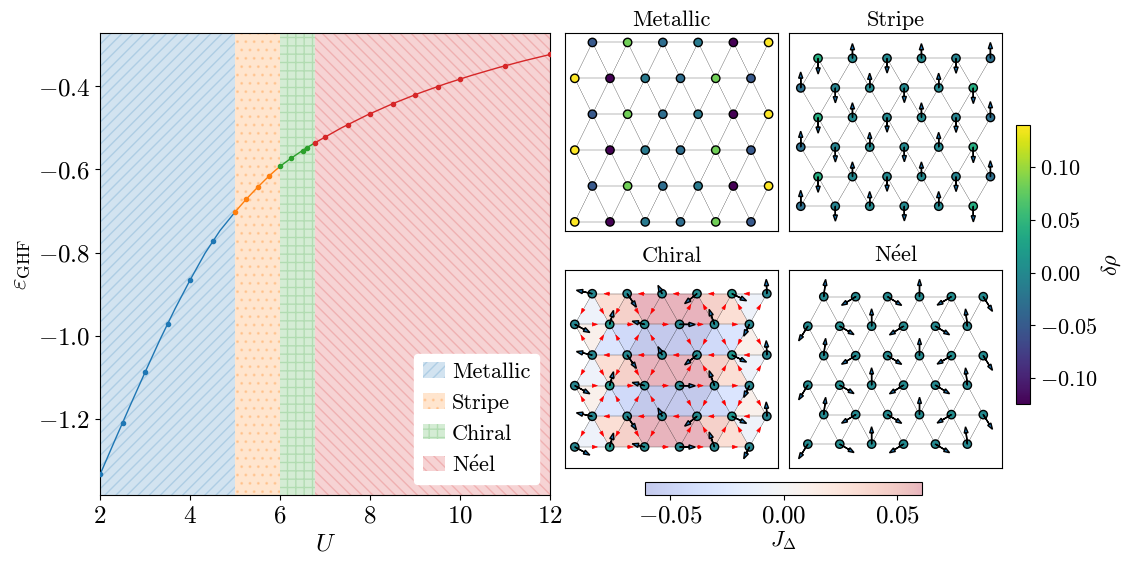

In [9]:
labels = ['Metallic', 'Stripe', 'Chiral', r'$\mathrm{N\acute{e}el}$']

# ----- create figure & layout -----
fig = plt.figure(figsize=(12, 6))

# Outer grid: 2 rows, 3 columns (left big panel + 2×2 block on the right)
outer = fig.add_gridspec(2, 3, width_ratios=[2, 1, 1], wspace=0.05, hspace=0.0)

# Big panel on the left spans both rows of the first column
ax_main = fig.add_subplot(outer[:, 0])

# 2×2 grid for the four phase panels on the right
right = outer[:, 1:].subgridspec(2, 2, wspace=0.05, hspace=0.2)

# four small panels on the right, one per row
ax_panels = [
    fig.add_subplot(right[0, 0]),
    fig.add_subplot(right[0, 1]),
    fig.add_subplot(right[1, 0]),
    fig.add_subplot(right[1, 1]),
]

# ----- ax_main -----
start = 0
hatches = ['///', '..', '++', '\\\\\\']

for i, dat in enumerate(xc_6x6_neel_dat_arr):
    ax_main.scatter(dat[:, 0], dat[:, 1], label=labels[i], color=colors[i], zorder=10, marker='.')
    
    len_x = dat[:, 0].shape[0]
    if (i == 1) or (i == len(xc_6x6_neel_dat_arr)-1): len_x -= 1
    end = start + len_x
    
    x_start = xc_6x6_all_dat[start, 0]
    x_end = xc_6x6_all_dat[end, 0]
    x = np.linspace(x_start, x_end, 10)
    y = xc_6x6_spl(x)
    
    ax_main.plot(x, y, lw=1)
    ax_main.axvspan(x_start, x_end, facecolor=colors[i], alpha=0.2)
    p = ax_main.axvspan(x_start, x_end, facecolor="none", edgecolor=colors[i], hatch=hatches[i], alpha=0.2)
    p.set_linewidth(0.0)

    start = end

# ax.grid()
from matplotlib.patches import Patch

handles = [
    Patch(
        facecolor=colors[i],
        edgecolor=colors[i],   # hatch color comes from edgecolor
        hatch=hatches[i],
        alpha=0.20,            # applies to face; hatch may look a bit stronger
        linewidth=0
    )
    for i in range(len(xc_6x6_neel_dat_arr))
]

leg = ax_main.legend(handles, labels, labelspacing=0.5, handletextpad=0.3, handlelength=1, facecolor="white", framealpha=1.)
leg.get_frame().set_edgecolor("1.")

ax_main.set_xlim(min(xc_6x6_all_dat[:, 0]), max(xc_6x6_all_dat[:, 0]))
ax_main.set_xlabel(r"$U$", fontsize=18)
ax_main.set_ylabel(r"$\varepsilon_\text{GHF}$", fontsize=18)

# ----- side panels -----
density_fluc_arr = density_arr - np.mean(density_arr)
vmin = np.amin(density_fluc_arr)
vmax = np.amax(density_fluc_arr)
y_boundary_pairs = [0., max(coords[:, 1])]
    
for i, ax in enumerate(ax_panels):
    # density = density_arr[i]
    density = density_fluc_arr[i]
    sz = sz_arr[i]
    sx = sx_arr[i]
    Jbond = Jbond_arr[i]
    plot_Jbond = True if np.amax(np.absolute(Jbond)) > 1e-9 else False
    
    im = ax.scatter(coords[:, 0], coords[:, 1], 
                    c=density, marker='o', 
                    cmap='viridis', edgecolor='k', 
                    vmin=vmin, vmax=vmax, zorder=5)
    # divider = make_axes_locatable(ax)
    # cax = divider.append_axes('right', size='5%', pad=0.05)
    # cbar = fig.colorbar(im, cax=cax, orientation='vertical')
    # cbar.ax.tick_params(labelsize=14)
    
    for j in range(n_sites):
        coord = coords[j]
        x, y = coord

        # Plot local spin.
        if i == 0: 
            arrow_size = 0
            head_width = 0
        else: 
            arrow_size = 0.7
            head_width = 0.12
        ax.arrow(
            x,
            y,
            arrow_size * sx.ravel()[j],
            arrow_size * sz.ravel()[j],
            head_width=head_width,
            zorder=10
        )

        # Draw lines to nearest neighbours.
        nn = np.nonzero(adjacency[j])[0]
        
        for n in nn:
            site_n = coords[n]
            x_n, y_n = site_n
            if np.allclose([y, y_n], y_boundary_pairs) or np.allclose([y, y_n], y_boundary_pairs[::-1]):
                continue
            ax.plot([x, x_n], [y, y_n], "k-", lw=0.1)

        # Plot bond charge current.
        if plot_Jbond:
            current_threshold = 1e-3
            current_scale = 0.5
            
            for n in nn:
                site_n = coords[n]
                x_n, y_n = site_n
                if n <= j: continue # Halve the work.

                if np.allclose([y, y_n], y_boundary_pairs) or np.allclose([y, y_n], y_boundary_pairs[::-1]):
                    continue
    
                J_jn = Jbond[j, n].real
                sign_J_jn = np.sign(J_jn)
                mag_J_jn = np.absolute(J_jn)
                
                if mag_J_jn < current_threshold: continue
    
                xm = 0.5 * (x + x_n)
                ym = 0.5 * (y + y_n)
                dx = x_n - x
                dy = y_n - y
                L = np.hypot(dx, dy)
                if L == 0: continue
                ux, uy = dx / L, dy / L
    
                direction = sign_J_jn
                length = current_scale * mag_J_jn
    
                ax.arrow(
                    xm,
                    ym,
                    direction * length * ux,
                    direction * length * uy,
                    head_width=0.1,
                    length_includes_head=False,
                    linewidth=0.4,
                    zorder=2.5,
                    color='r',
                )

    if plot_Jbond:
        from matplotlib.collections import PolyCollection

        plaquette, plaquette_coords, J_plaquettes = get_plaquette_charge_current(lattice, Jbond)
        pc = PolyCollection(
                    plaquette_coords,
                    array=np.array(J_plaquettes).real,
                    cmap='coolwarm',
                    alpha=0.3,
                    edgecolors="none",
                    zorder=0.5,
                )
        ax.add_collection(pc)
        
    # ax.set_aspect('equal')
    ax.set_title(labels[i], fontsize=16)
    ax.tick_params(left=False, labelleft=False,
                   bottom=False, labelbottom=False)

    # put the label just above the axes, without affecting layout
    # ax.text(
    #     0.5, 1.02, labels[i],
    #     transform=ax.transAxes,
    #     ha="center", va="bottom", fontsize=16
    # )

cbar = fig.colorbar(
    im,
    ax=ax_panels,      # all four axes share this colorbar
    location="right",    # needs mpl>=3.6; otherwise orientation="vertical"
    fraction=0.03,      # width of cbar relative to its region
    pad=0.03             # space between panels and cbar
)
cbar.ax.tick_params(labelsize=16)
cbar.set_label(r'$\delta \rho$', fontsize=16, labelpad=1)

cbar2 = fig.colorbar(
    pc, 
    ax=ax_panels,
    location="bottom",
    orientation="horizontal",
    fraction=0.03,      # width of cbar relative to its region
    pad=0.03             # space between panels and cbar
)
cbar.ax.tick_params(labelsize=16)
cbar2.set_label(r"$J_\Delta$", fontsize=16, labelpad=1)   

# plt.tight_layout()
# plt.savefig('../figs/xc_6x6_ghf_scan_u.pdf', format='pdf', dpi=300)